# 📊 Notebook 01 — Exploratory Data Analysis (EDA)
**Projet :** Cervical Cancer Risk Prediction  
**Auteure :** Hadil Dhaya - 4th Year Data Science - Group 5 - 2026
**Dataset :** UCI — Cervical Cancer Risk Factors (858 patients, 36 features)

---
**Objectifs de ce notebook :**
- Charger et inspecter le dataset
- Analyser les valeurs manquantes
- Comprendre la distribution des features
- Identifier le déséquilibre de classes
- Sauvegarder les graphiques dans `outputs/`

## 0. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

os.makedirs('../outputs', exist_ok=True)
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement du dataset

In [7]:
df = pd.read_csv('../data/risk_factors_cervical_cancer.csv', na_values='?')
print(f'Shape : {df.shape}')
print(f'Colonnes : {df.columns.tolist()}')

Shape : (858, 36)
Colonnes : ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']


In [6]:
df.head(10)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.000000,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.000000,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
5,42,3.0,23.0,2.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
6,51,3.0,17.0,6.0,1.0,34.000000,3.4,0.0,0.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,1,1,0,1
7,26,1.0,26.0,3.0,0.0,0.000000,0.0,1.0,2.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
8,45,1.0,20.0,5.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,1,0,0,0,0
9,44,3.0,15.0,NaN,1.0,1.266973,2.8,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [8]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.82,8.50,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.53,1.67,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,17.00,2.80,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.28,1.45,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.15,0.35,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.22,4.09,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.45,2.23,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.64,0.48,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.26,3.76,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.11,0.32,0.0,0.0,0.0,0.0,1.0


## 2. Analyse des valeurs manquantes

In [9]:
missing = pd.DataFrame({
    'Nombre de NaN'   : df.isnull().sum(),
    'Pourcentage (%)' : (df.isnull().mean() * 100).round(2)
}).sort_values('Pourcentage (%)', ascending=False)

print('=== Colonnes avec valeurs manquantes ===')
print(missing[missing['Nombre de NaN'] > 0].to_string())

=== Colonnes avec valeurs manquantes ===
                                    Nombre de NaN  Pourcentage (%)
STDs: Time since last diagnosis               787            91.72
STDs: Time since first diagnosis              787            91.72
IUD                                           117            13.64
IUD (years)                                   117            13.64
Hormonal Contraceptives                       108            12.59
Hormonal Contraceptives (years)               108            12.59
STDs:pelvic inflammatory disease              105            12.24
STDs:vulvo-perineal condylomatosis            105            12.24
STDs:HPV                                      105            12.24
STDs:Hepatitis B                              105            12.24
STDs:HIV                                      105            12.24
STDs:AIDS                                     105            12.24
STDs:molluscum contagiosum                    105            12.24
STDs:genital herpes  

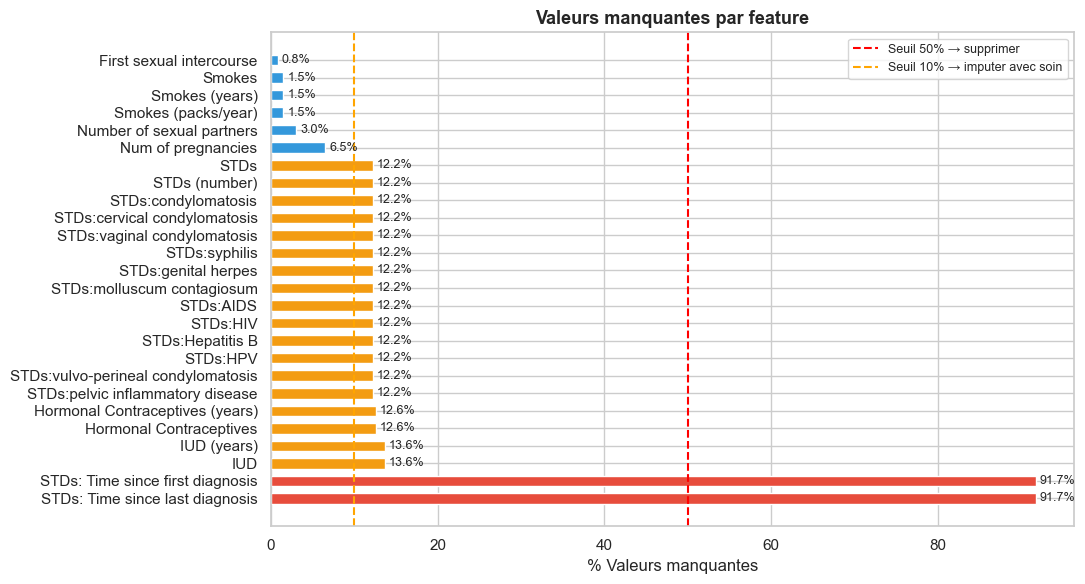

Sauvegardé : outputs/missing_values.png


In [10]:
missing_plot = missing[missing['Pourcentage (%)'] > 0]

plt.figure(figsize=(11, 6))
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#3498db'
          for v in missing_plot['Pourcentage (%)']]
bars = plt.barh(missing_plot.index, missing_plot['Pourcentage (%)'],
                color=colors, edgecolor='white', height=0.6)
plt.axvline(x=50, color='red',    linestyle='--', lw=1.5, label='Seuil 50% → supprimer')
plt.axvline(x=10, color='orange', linestyle='--', lw=1.5, label='Seuil 10% → imputer avec soin')
for bar, val in zip(bars, missing_plot['Pourcentage (%)']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.xlabel('% Valeurs manquantes'); plt.legend(fontsize=9)
plt.title('Valeurs manquantes par feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/missing_values.png', dpi=150)
plt.show()
print('Sauvegardé : outputs/missing_values.png')

## 3. Variable cible — Biopsy

In [10]:
counts = df['Biopsy'].value_counts()
pct    = df['Biopsy'].value_counts(normalize=True) * 100
print(f'0 — No Cancer : {counts[0]} ({pct[0]:.1f}%)')
print(f'1 — Cancer    : {counts[1]} ({pct[1]:.1f}%)')
print(f'Ratio déséquilibre : {counts[0]/counts[1]:.0f}:1  →  SMOTE nécessaire')

0 — No Cancer : 803 (93.6%)
1 — Cancer    : 55 (6.4%)
Ratio déséquilibre : 15:1  →  SMOTE nécessaire


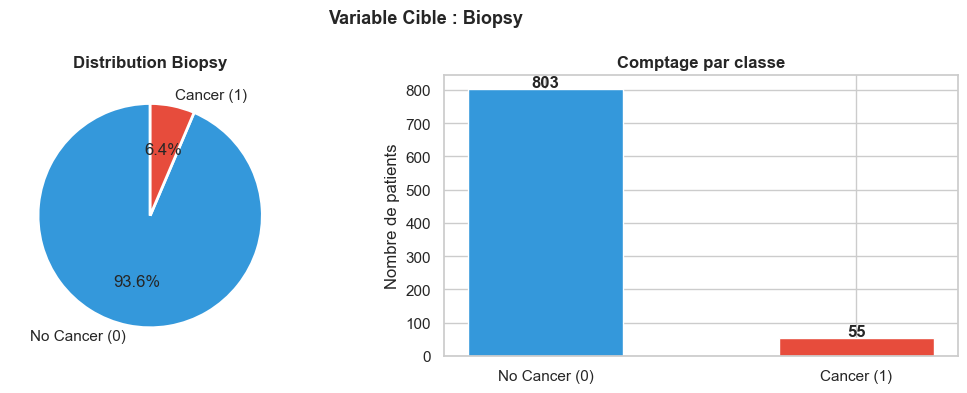

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(counts, labels=['No Cancer (0)', 'Cancer (1)'],
            colors=['#3498db','#e74c3c'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribution Biopsy', fontweight='bold')
bars = axes[1].bar(['No Cancer (0)','Cancer (1)'], counts.values,
                   color=['#3498db','#e74c3c'], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(v), ha='center', fontweight='bold')
axes[1].set_ylabel('Nombre de patients')
axes[1].set_title('Comptage par classe', fontweight='bold')
plt.suptitle('Variable Cible : Biopsy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=150)
plt.show()

## 4. Distributions des features numériques

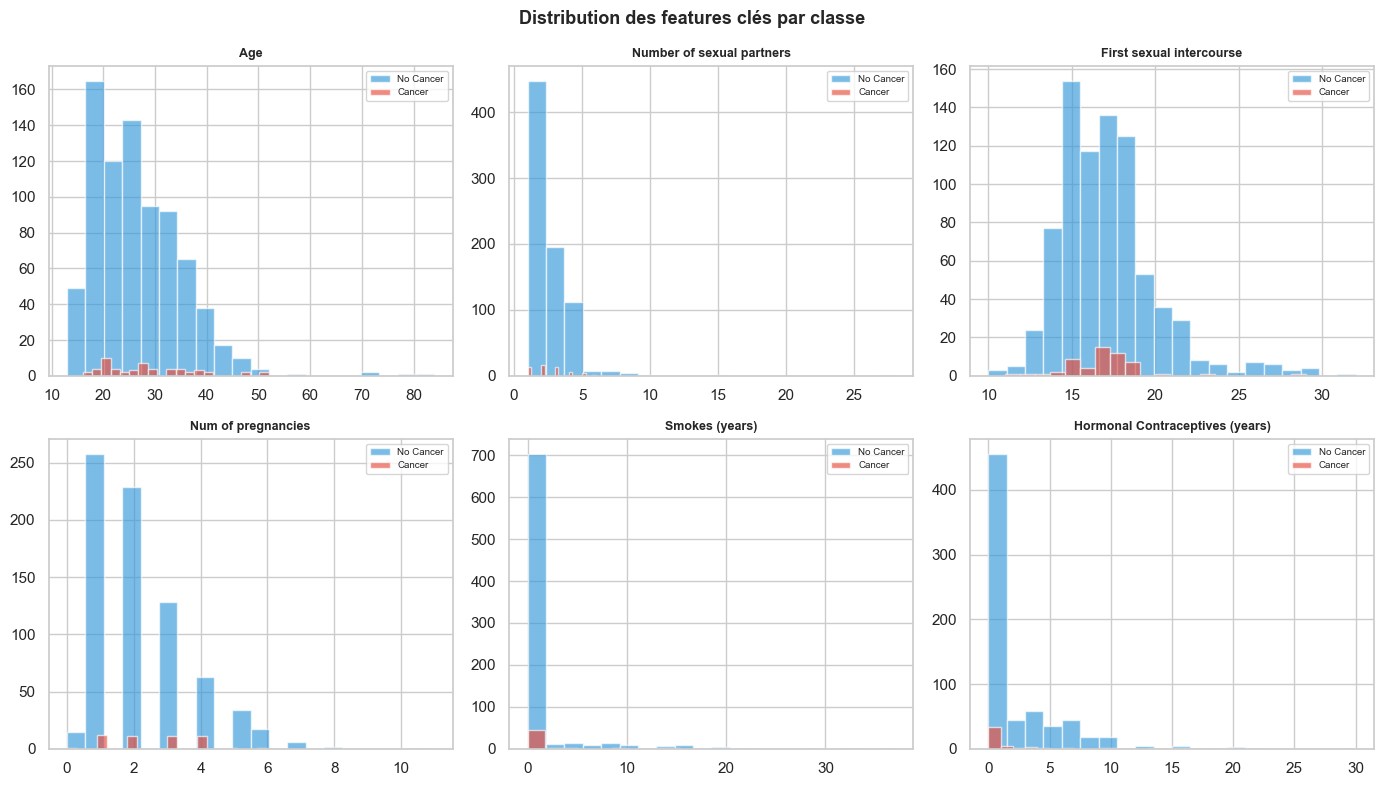

In [12]:
features_to_plot = ['Age','Number of sexual partners','First sexual intercourse',
                    'Num of pregnancies','Smokes (years)','Hormonal Contraceptives (years)']
features_to_plot = [f for f in features_to_plot if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    for val, color, label in [(0,'#3498db','No Cancer'),(1,'#e74c3c','Cancer')]:
        df[df['Biopsy']==val][feat].dropna().hist(
            bins=20, ax=axes[i], alpha=0.65, color=color, label=label)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribution des features clés par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/feature_distributions.png', dpi=150)
plt.show()

## 5. Boxplots — Détection des outliers

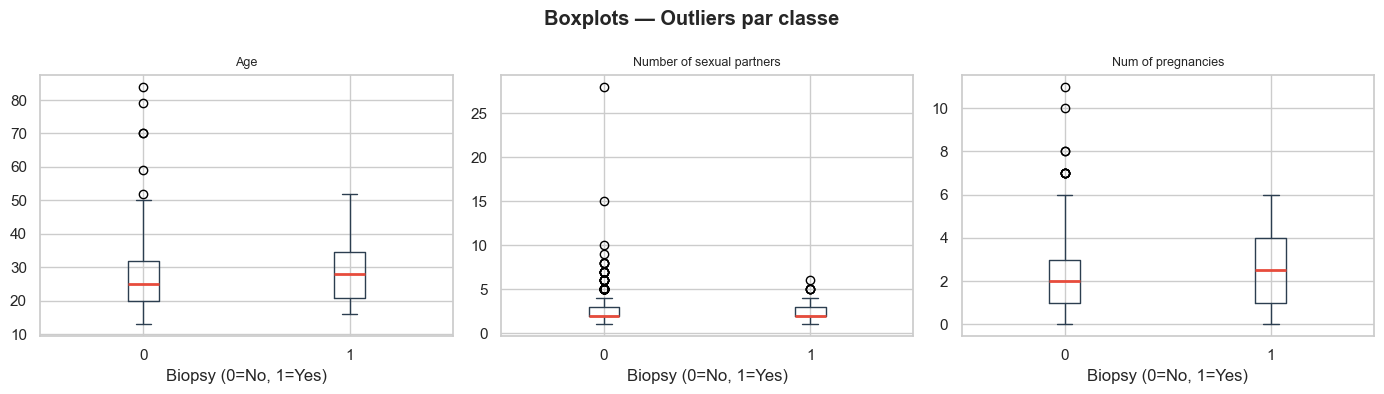

In [13]:
box_feats = ['Age','Number of sexual partners','Num of pregnancies']
box_feats = [f for f in box_feats if f in df.columns]
fig, axes = plt.subplots(1, len(box_feats), figsize=(14, 4))
for ax, feat in zip(axes, box_feats):
    df.boxplot(column=feat, by='Biopsy', ax=ax,
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2),
               whiskerprops=dict(color='#2c3e50'),
               capprops=dict(color='#2c3e50'))
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Biopsy (0=No, 1=Yes)')
plt.suptitle('Boxplots — Outliers par classe', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/boxplots.png', dpi=150)
plt.show()

## 6. Matrice de corrélation

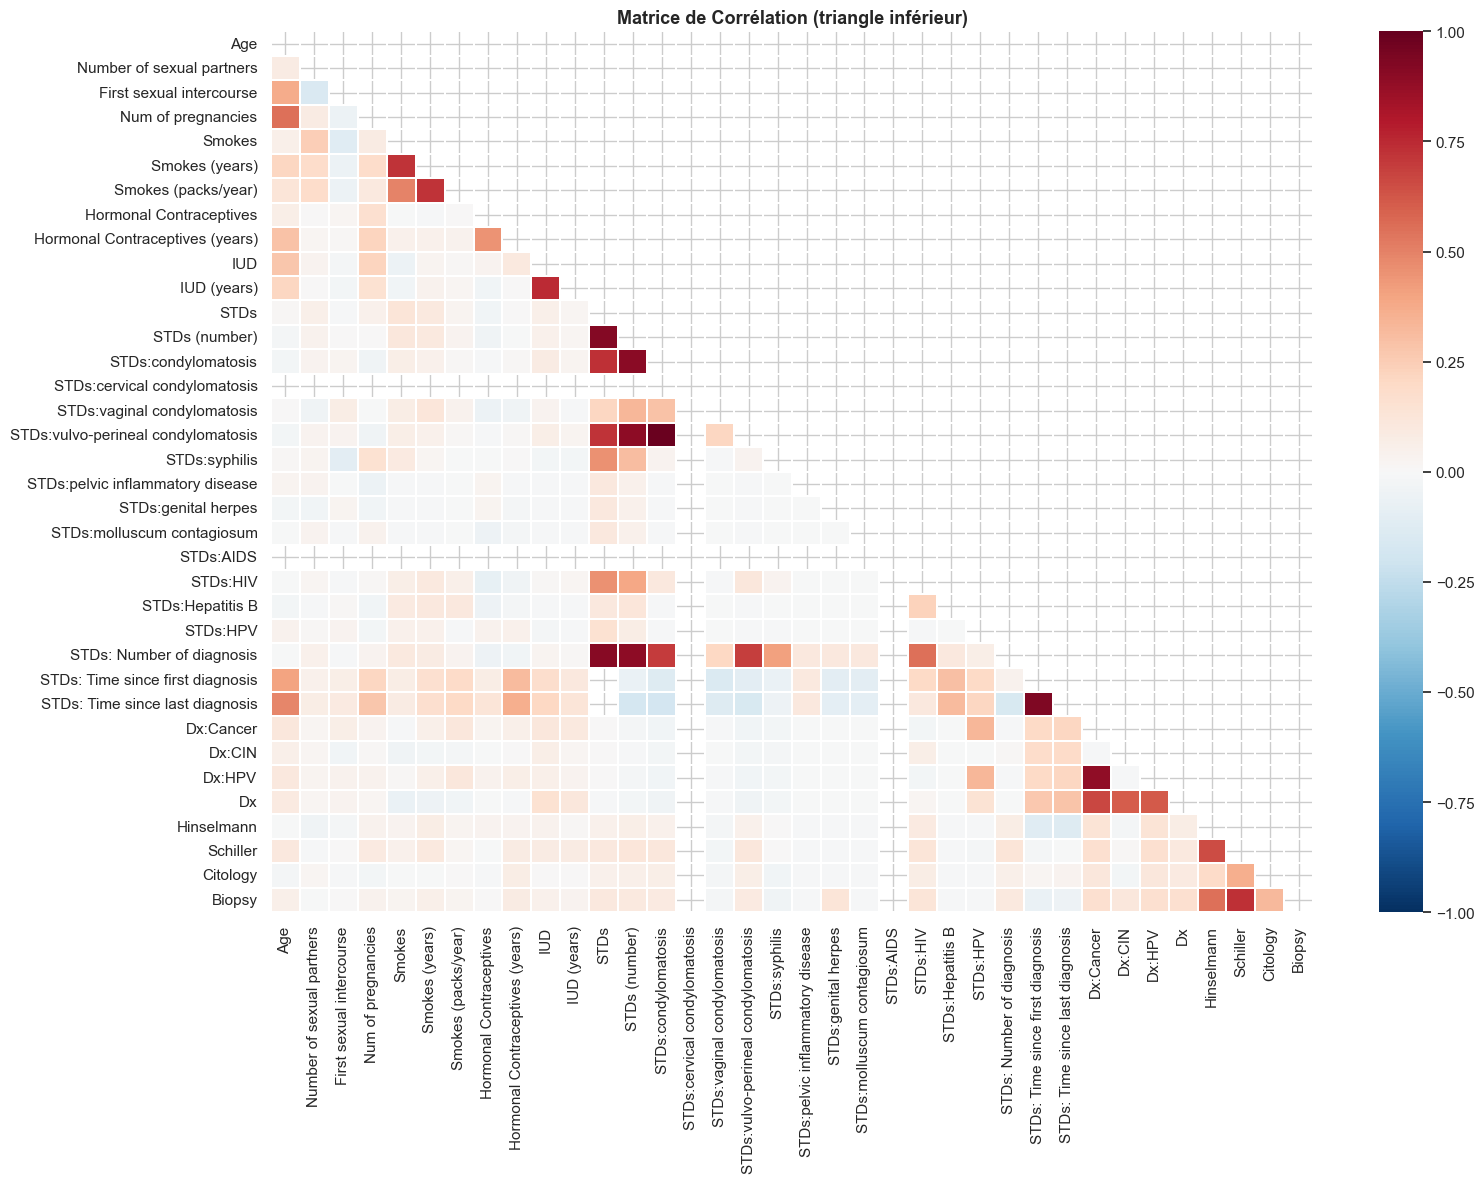


=== Top 10 corrélations avec Biopsy ===
Biopsy                 1.000
Schiller               0.733
Hinselmann             0.547
Citology               0.327
Dx:Cancer              0.161
Dx:HPV                 0.161
Dx                     0.158
STDs:genital herpes    0.133
STDs:HIV               0.127
Dx:CIN                 0.113
STDs                   0.109


In [14]:
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3, vmin=-1, vmax=1)
plt.title('Matrice de Corrélation (triangle inférieur)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', dpi=150)
plt.show()

print('\n=== Top 10 corrélations avec Biopsy ===')
print(corr['Biopsy'].abs().sort_values(ascending=False).head(11).round(3).to_string())

## 7. Résumé EDA

In [15]:
print('=' * 55)
print('  RÉSUMÉ EDA')
print('=' * 55)
print(f'  Shape dataset       : {df.shape}')
print(f'  Cas Cancer (Biopsy=1): {df["Biopsy"].sum()} ({df["Biopsy"].mean()*100:.1f}%)')
print(f'  Cols > 80% NaN      : {(df.isnull().mean() > 0.80).sum()} → à supprimer')
print(f'  Cols > 0%  NaN      : {(df.isnull().sum() > 0).sum()} → à imputer')
print(f'  Déséquilibre classes : OUI → utiliser SMOTE')
print(f'  Outliers détectés    : Age, Partners, Pregnancies')
print('=' * 55)
print('✅ EDA terminée → lancer 02_Preprocessing.ipynb')

  RÉSUMÉ EDA
  Shape dataset       : (858, 36)
  Cas Cancer (Biopsy=1): 55 (6.4%)
  Cols > 80% NaN      : 2 → à supprimer
  Cols > 0%  NaN      : 26 → à imputer
  Déséquilibre classes : OUI → utiliser SMOTE
  Outliers détectés    : Age, Partners, Pregnancies
✅ EDA terminée → lancer 02_Preprocessing.ipynb
